In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [10]:
data = pd.read_csv("Dataset\BOM.csv")

<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Acer\AppData\Local\Temp\ipykernel_10064\2660600984.py:1: SyntaxWarning: invalid escape sequence '\B'
  data = pd.read_csv("Dataset\BOM.csv")


In [11]:
data.head(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,W,19.0,24.0,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,W,20.0,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,W,6.0,17.0,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,NW,7.0,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,SSE,15.0,11.0,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


In [12]:
cont_col = [2,3,4,15,16,18,19,20 ]
desc_col = [11,12,13,17,14,5,6,8]
catego = [1,7,9,10,21,22]

In [13]:

for col in cont_col:
    # اگر ستون عددی نیست، عددی‌اش می‌کنیم تا mean قابل محاسبه باشد
    data.iloc[:, col] = np.nan_to_num(
        pd.to_numeric(data.iloc[:, col], errors="coerce"),
        nan=np.nan
    )
    mean_val = data.iloc[:, col].mean(skipna=True)
    data.iloc[:, col] = data.iloc[:, col].fillna(mean_val)

# 2) گسسته‌ها: مود
for col in desc_col:
    s = data.iloc[:, col]
    mode_series = s.mode(dropna=True)
    mode_val = mode_series.iloc[0] if len(mode_series) > 0 else np.nan
    data.iloc[:, col] = s.fillna(mode_val)

# 3) کتگوریکال‌ها: مود
for col in catego:
    s = data.iloc[:, col]
    mode_series = s.mode(dropna=True)
    mode_val = mode_series.iloc[0] if len(mode_series) > 0 else np.nan
    data.iloc[:, col] = s.fillna(mode_val)

# (اختیاری) چک تعداد نال‌ها بعد از پرکردن
print(data.isna().sum().sum())


0


In [14]:
data.isna().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [15]:
data.columns = range(data.shape[1]) 

In [16]:

num_cols = cont_col + desc_col




scaler = StandardScaler()
data.iloc[:, num_cols] = scaler.fit_transform(data.iloc[:, num_cols])




normalizer = MinMaxScaler()
data.iloc[:, num_cols] = normalizer.fit_transform(data.iloc[:, num_cols])


In [17]:
data.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,2008-12-01,Albury,0.516509,0.523629,0.001617,0.027586,0.0,W,0.294574,W,WNW,0.153846,0.275862,0.71,0.22,0.449587,0.4800,0.888889,0.501103,0.508439,0.522073,No,No
1,2008-12-02,Albury,0.375000,0.565217,0.000000,0.027586,0.0,WNW,0.294574,NNW,WSW,0.030769,0.252874,0.44,0.25,0.497521,0.4912,0.777778,0.501103,0.514768,0.570058,No,No
2,2008-12-03,Albury,0.504717,0.576560,0.000000,0.027586,0.0,WSW,0.310078,W,WSW,0.146154,0.298851,0.38,0.30,0.447934,0.5056,0.777778,0.222222,0.594937,0.548944,No,No
3,2008-12-04,Albury,0.417453,0.620038,0.000000,0.027586,0.0,NE,0.139535,SE,E,0.084615,0.103448,0.45,0.16,0.613223,0.5712,0.777778,0.501103,0.533755,0.612284,No,No
4,2008-12-05,Albury,0.613208,0.701323,0.002695,0.027586,0.0,W,0.271318,ENE,NW,0.053846,0.229885,0.82,0.33,0.500826,0.4624,0.777778,0.888889,0.527426,0.673704,No,No
5,2008-12-06,Albury,0.544811,0.652174,0.000539,0.027586,0.0,WNW,0.387597,W,W,0.146154,0.275862,0.55,0.23,0.474380,0.4528,0.777778,0.501103,0.586498,0.658349,No,No
6,2008-12-07,Albury,0.537736,0.563327,0.000000,0.027586,0.0,W,0.341085,SW,W,0.153846,0.275862,0.49,0.19,0.480992,0.4976,0.111111,0.501103,0.533755,0.575816,No,No
7,2008-12-08,Albury,0.382075,0.595463,0.000000,0.027586,0.0,W,0.224806,SSE,W,0.046154,0.195402,0.48,0.19,0.543802,0.5280,0.777778,0.501103,0.495781,0.593090,No,No
8,2008-12-09,Albury,0.429245,0.693762,0.000000,0.027586,0.0,NNW,0.573643,SE,NW,0.053846,0.321839,0.42,0.09,0.469421,0.4240,0.777778,0.501103,0.537975,0.683301,No,Yes
9,2008-12-10,Albury,0.509434,0.659735,0.003774,0.027586,0.0,W,0.170543,S,SSE,0.115385,0.126437,0.58,0.27,0.438017,0.4576,0.777778,0.501103,0.575949,0.644914,Yes,No


In [18]:
data.iloc[:, [21, 22]] = data.iloc[:, [21, 22]].replace({"No": 0, "Yes": 1})


data = pd.get_dummies(data, columns=[data.columns[1], data.columns[7], data.columns[9], data.columns[10]])

C:\Users\Acer\AppData\Local\Temp\ipykernel_10064\3113634326.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.iloc[:, [21, 22]] = data.iloc[:, [21, 22]].replace({"No": 0, "Yes": 1})


In [19]:
data.head(10)

,0,2,3,4,5,6,8,11,12,13,14,15,16,17,18,19,20,21,22,1_Adelaide,1_Albany,1_Albury,1_AliceSprings,1_BadgerysCreek,1_Ballarat,1_Bendigo,1_Brisbane,1_Cairns,1_Canberra,1_Cobar,1_CoffsHarbour,1_Dartmoor,1_Darwin,1_GoldCoast,1_Hobart,1_Katherine,1_Launceston,1_Melbourne,1_MelbourneAirport,1_Mildura,...,7_S,7_SE,7_SSE,7_SSW,7_SW,7_W,7_WNW,7_WSW,9_E,9_ENE,9_ESE,9_N,9_NE,9_NNE,9_NNW,9_NW,9_S,9_SE,9_SSE,9_SSW,9_SW,9_W,9_WNW,9_WSW,10_E,10_ENE,10_ESE,10_N,10_NE,10_NNE,10_NNW,10_NW,10_S,10_SE,10_SSE,10_SSW,10_SW,10_W,10_WNW,10_WSW
0,2008-12-01,0.516509,0.523629,0.001617,0.027586,0.0,0.294574,0.153846,0.275862,0.71,0.22,0.449587,0.4800,0.888889,0.501103,0.508439,0.522073,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2008-12-02,0.375000,0.565217,0.000000,0.027586,0.0,0.294574,0.030769,0.252874,0.44,0.25,0.497521,0.4912,0.777778,0.501103,0.514768,0.570058,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2008-12-03,0.504717,0.576560,0.000000,0.027586,0.0,0.310078,0.146154,0.298851,0.38,0.30,0.447934,0.5056,0.777778,0.222222,0.594937,0.548944,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,2008-12-04,0.417453,0.620038,0.000000,0.027586,0.0,0.139535,0.084615,0.103448,0.45,0.16,0.613223,0.5712,0.777778,0.501103,0.533755,0.612284,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2008-12-05,0.613208,0.701323,0.002695,0.027586,0.0,0.271318,0.053846,0.229885,0.82,0.33,0.500826,0.4624,0.777778,0.888889,0.527426,0.673704,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
5,2008-12-06,0.544811,0.652174,0.000539,0.027586,0.0,0.387597,0.146154,0.275862,0.55,0.23,0.474380,0.4528,0.777778,0.501103,0.586498,0.658349,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
6,2008-12-07,0.537736,0.563327,0.000000,0.027586,0.0,0.341085,0.153846,0.275862,0.49,0.19,0.480992,0.4976,0.111111,0.501103,0.533755,0.575816,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False

In [20]:
data = data.drop(columns=[data.columns[0]], errors="ignore")   # اگر ستون 0 همان Date است
data = data.apply(pd.to_numeric, errors="ignore")              # بقیه ستون‌ها

C:\Users\Acer\AppData\Local\Temp\ipykernel_10064\1927089479.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")              # بقیه ستون‌ها


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Columns: 115 entries, 2 to 10_WSW
dtypes: bool(97), float64(16), int64(2)
memory usage: 33.4 MB


In [22]:
data.columns = data.columns.astype(str)

X = data.drop(data.columns[22], axis=1)
y = data.iloc[:, 22]


X = data.drop(data.columns[22], axis=1)
y = data.iloc[:, 22]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

k_values = range(1, 5)
acc_list = []
f1_list = []

best_k = None
best_f1 = -1

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    acc_list.append(acc)
    f1_list.append(f1)

    if f1 > best_f1:
        best_f1 = f1
        best_k = k

print("Best k:", best_k)
print("Best F1:", best_f1)


Best k: 2
Best F1: 0.44042232277526394


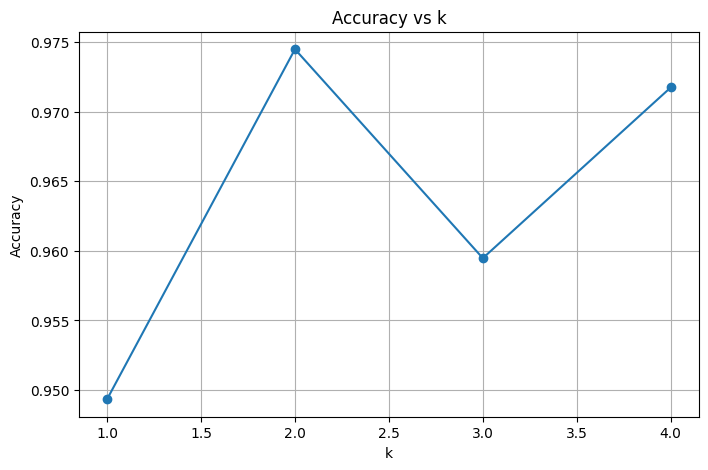

In [23]:
plt.figure(figsize=(8,5))
plt.plot(k_values, acc_list, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.grid(True)
plt.show()

به علت طولانی بودن محاسبات بخاطر حجم بالای دیتا کا را از یک تا 5 بررسی کردیم و کا شماره 2 از بقیه دقیق تر بود

---------------

پاسخ سوال :

درخت تصمیم برای تصمیم گیری های ریل تایم خیلی بهتره 


چون سرعت بالاتری داره و در لحظه بهتر میتونه کار کنه

ا زاون طرف هم الگوریتم کا نزدیکترین همسایه بابت تنل بودن و اینکه دیتای آموزش رو فقط انگار میبینه کجاست و وقتی ازش 
پیش بینی میخوایم برامون محاسبه انجام میده به همین علت سرعتش کند تره و برای دیتا ست های بررگ اصلا خوب نیست 


شاید کا نزدیکترین همسایه بتونه توی بعضی از پیچیدگی ها تاحدی بهتر عمل کنه ولی در بحث سرعت ضعف  داره و برای مواقعی که به صورت 
ریل تایم ازش پاسخ بخوایم نمیتونه خوب عمل کنه

--------------------

بنظرم بهتر بود کاهش ابعاد میدادیم 

-----

یک کار دیگه هم که میتونست موثر واقع بشه پاک کردن ردیف های دارای ماقادیر گمشده هست 
چون دیتاست بزرگ هست حذف کردن اونها زیاد نمیتونه مدل رو ضعیف کنه
ستون هایی که تاثیر زیادی دارن و مدل رو میتونن قوی کنن رو مقادیر گمشده رو 
یا مقدارمناسب جایگزین می کردیم و ستون هایی که اهمیت کمتری دارن رو میشد 

حتی پاک کرد 

البته که باید با تکرار و تمرین به این نتایج دست پیدا کرد.

In [27]:

k_values = range(1, 10)
acc_list = []
f1_list = []

best_k = None
best_f1 = -1

for k in k_values:
    model = DecisionTreeClassifier(max_depth=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    acc_list.append(acc)
    f1_list.append(f1)

    if f1 > best_f1:
        best_f1 = f1
        best_k = k

print("Best k:", best_k)
print("Best F1:", best_f1)

Best k: 8
Best F1: 0.215633423180593


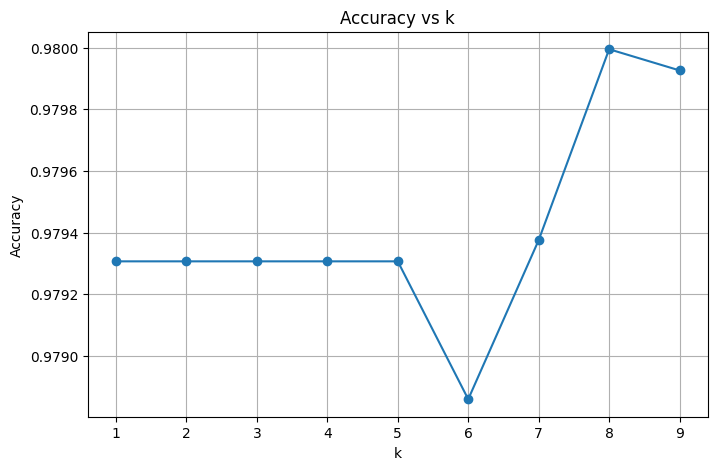

In [28]:
plt.figure(figsize=(8,5))
plt.plot(k_values, acc_list, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.grid(True)
plt.show()